<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/Taller_PSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Taller - Análisis de Señales Armónicas con Ruido: Estimación de PSD, Autocorrelación y Estadísticos Básicos.
##Julian David Morales Pineda

estimación de las componentes de la señal x(t)=a
1
​
 cos(ω
1
​
 t+ϕ
1
​
 )+a
2
​
 cos(ω
2
​
 t+ϕ
2
​
 )+η(t): dónde n(t) es ruido Gaussiano

--- Estimating for 1 Cosine ---
Estimated Freq: 50.00 Hz | True Freq: 50.00 Hz
Estimated Amplitude: 1.4688 | True: 1.5
Estimated Phase: 0.7731 | True: 0.7854

--- Estimating for 2 Cosines ---
Estimated Freqs: 50.00 Hz & 150.00 Hz
True Freqs: 50.00 Hz & 150.00 Hz
Estimated Amp 1: 1.4688 | True: 1.5
Estimated Phase 1: 0.7731 | True: 0.7854
Estimated Amp 2: 0.7123 | True: 0.7
Estimated Phase 2: -4.7051 | True: 1.5708


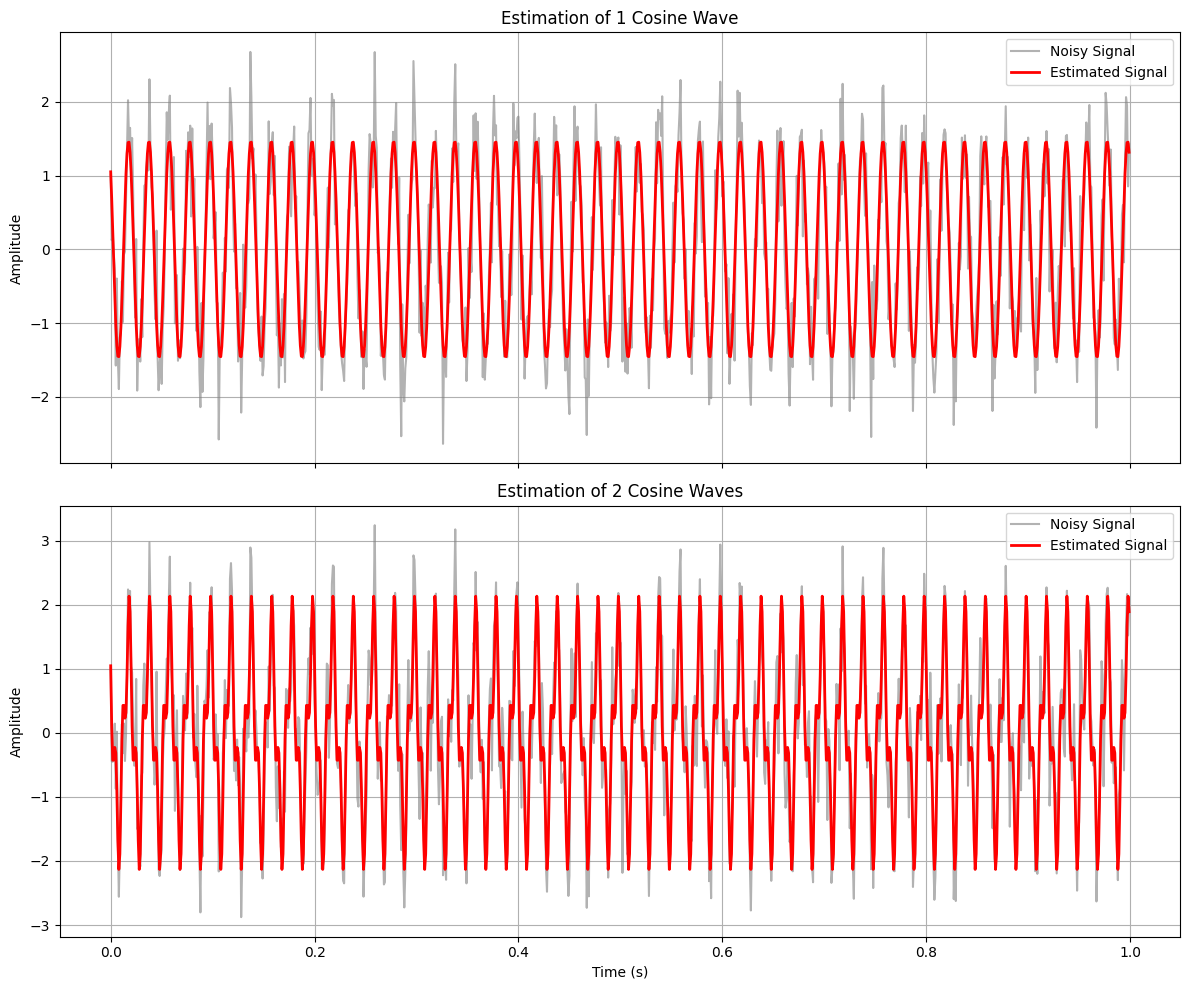

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- 1. Generate Signal with Noise ---
Fs = 1000       # Sampling frequency (Hz)
T = 1           # Signal duration (s)
t = np.linspace(0, T, Fs, endpoint=False) # Time vector
N = len(t)

# Parameters for a single cosine
a1_true = 1.5
w1_true = 2 * np.pi * 50  # 50 Hz
phi1_true = np.pi / 4

# Parameters for an additional cosine (for the 2-cosine case)
a2_true = 0.7
w2_true = 2 * np.pi * 150 # 150 Hz
phi2_true = np.pi / 2

# Gaussian noise
noise = np.random.normal(0, 0.5, N)

# Signals
x_1_cosine = a1_true * np.cos(w1_true * t + phi1_true) + noise
x_2_cosines = x_1_cosine + a2_true * np.cos(w2_true * t + phi2_true)

# --- 2. Estimation for 1 Cosine ---
print("--- Estimating for 1 Cosine ---")
# Find frequency using FFT
fft_signal = np.fft.fft(x_1_cosine)
frequencies = np.fft.fftfreq(N, 1/Fs)
positive_freqs = frequencies[:N // 2]
magnitude = np.abs(fft_signal)[:N // 2]
peak_freq_idx = np.argmax(magnitude)
estimated_w1 = 2 * np.pi * positive_freqs[peak_freq_idx]

# Model and curve fit
def cosine_model_1(t_fit, a_est, phi_est):
    return a_est * np.cos(estimated_w1 * t_fit + phi_est)

popt, pcov = curve_fit(cosine_model_1, t, x_1_cosine)
a1_est, phi1_est = popt

print(f"Estimated Freq: {estimated_w1 / (2*np.pi):.2f} Hz | True Freq: {w1_true / (2*np.pi):.2f} Hz")
print(f"Estimated Amplitude: {a1_est:.4f} | True: {a1_true}")
print(f"Estimated Phase: {phi1_est:.4f} | True: {phi1_true:.4f}")

# --- 3. Estimation for 2 Cosines ---
print("\n--- Estimating for 2 Cosines ---")
# Find two main frequencies using FFT
fft_2_cosines = np.fft.fft(x_2_cosines)
magnitude_2c = np.abs(fft_2_cosines)[:N // 2]
peak_indices = np.argsort(magnitude_2c)[-2:]
estimated_w1_2c = 2 * np.pi * positive_freqs[peak_indices[1]]
estimated_w2_2c = 2 * np.pi * positive_freqs[peak_indices[0]]

# Model and curve fit
def cosine_model_2(t_fit, a1_est, phi1_est, a2_est, phi2_est):
    return a1_est * np.cos(estimated_w1_2c * t_fit + phi1_est) + \
           a2_est * np.cos(estimated_w2_2c * t_fit + phi2_est)

initial_guess = [1, 0, 0.5, 0] # Initial guess for a, phi, a, phi
popt_2c, pcov_2c = curve_fit(cosine_model_2, t, x_2_cosines, p0=initial_guess)
a1_est_2c, phi1_est_2c, a2_est_2c, phi2_est_2c = popt_2c

print(f"Estimated Freqs: {estimated_w1_2c / (2*np.pi):.2f} Hz & {estimated_w2_2c / (2*np.pi):.2f} Hz")
print(f"True Freqs: {w1_true / (2*np.pi):.2f} Hz & {w2_true / (2*np.pi):.2f} Hz")
print(f"Estimated Amp 1: {a1_est_2c:.4f} | True: {a1_true}")
print(f"Estimated Phase 1: {phi1_est_2c:.4f} | True: {phi1_true:.4f}")
print(f"Estimated Amp 2: {a2_est_2c:.4f} | True: {a2_true}")
print(f"Estimated Phase 2: {phi2_est_2c:.4f} | True: {phi2_true:.4f}")

# --- 4. Plotting the results ---
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot for 1 cosine
axs[0].plot(t, x_1_cosine, label='Noisy Signal', color='gray', alpha=0.6)
axs[0].plot(t, cosine_model_1(t, a1_est, phi1_est), label='Estimated Signal', color='red', linewidth=2)
axs[0].set_title('Estimation of 1 Cosine Wave')
axs[0].set_ylabel('Amplitude')
axs[0].legend()
axs[0].grid(True)

# Plot for 2 cosines
axs[1].plot(t, x_2_cosines, label='Noisy Signal', color='gray', alpha=0.6)
axs[1].plot(t, cosine_model_2(t, *popt_2c), label='Estimated Signal', color='red', linewidth=2)
axs[1].set_title('Estimation of 2 Cosine Waves')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Amplitude')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

##Reducción de la perturbación para obtener los valores correctos. Se debe estimar utilizando un coseno, 2 cosenos, con frecuencia centralizada


--- Resultados de Media y Varianza ---
Frecuencia   | Media (Ruido)   | Media (Prom.)   | Varianza (Ruido)   | Varianza (Prom.)  
-------------------------------------------------------------------------------------
10           | 0.0023          | -0.0002         | 0.7450             | 0.5022            
100          | 0.0042          | -0.0004         | 0.7548             | 0.5024            
1000         | 0.0027          | 0.0003          | 0.7526             | 0.5030            


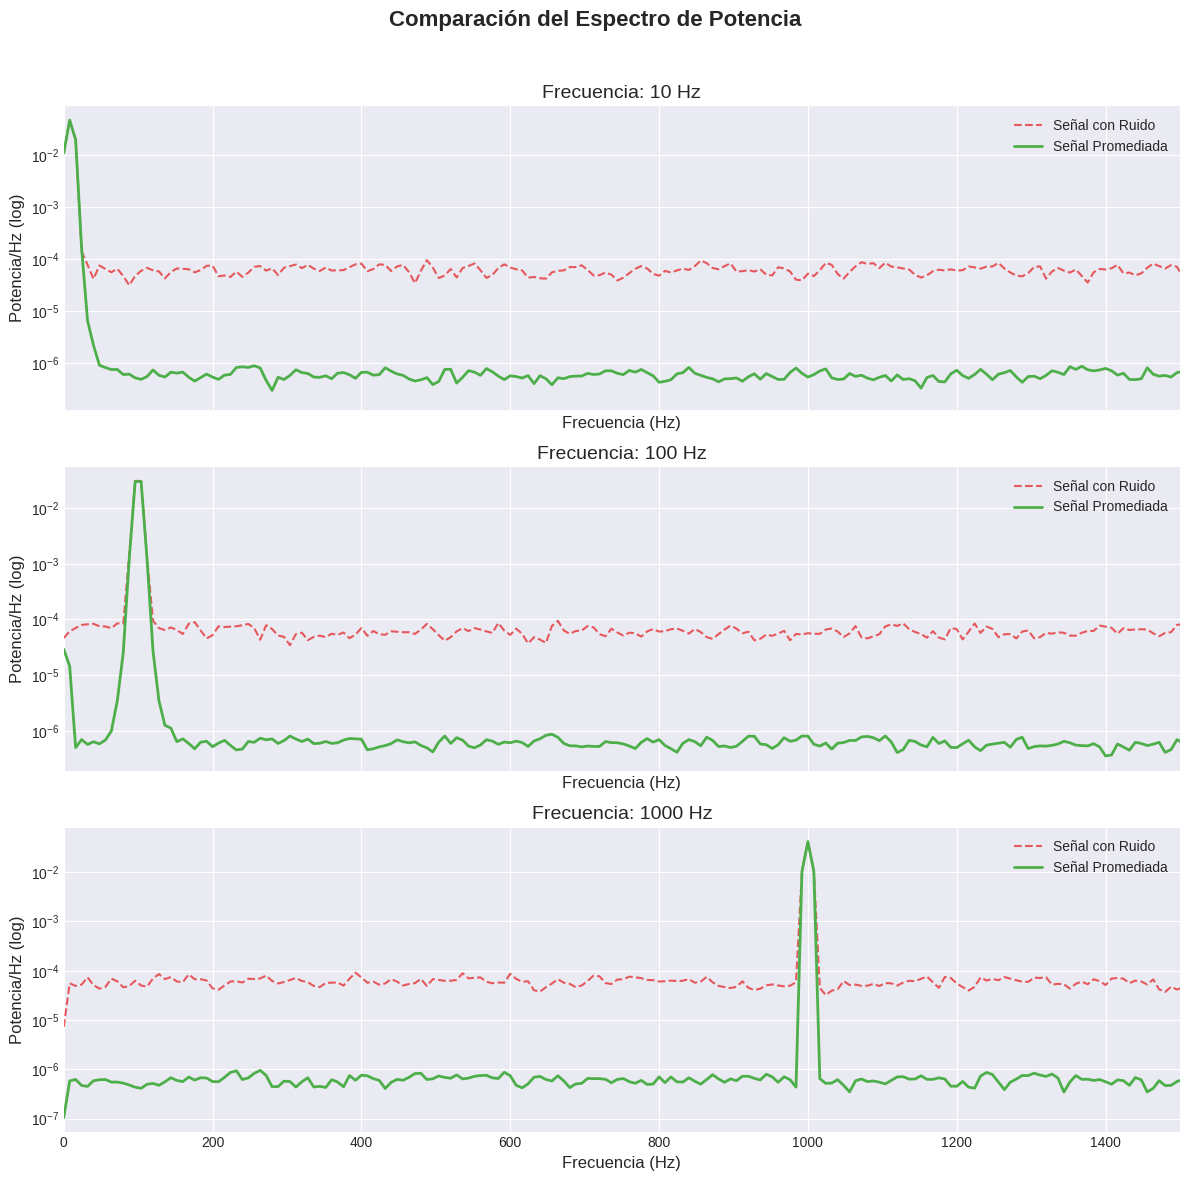

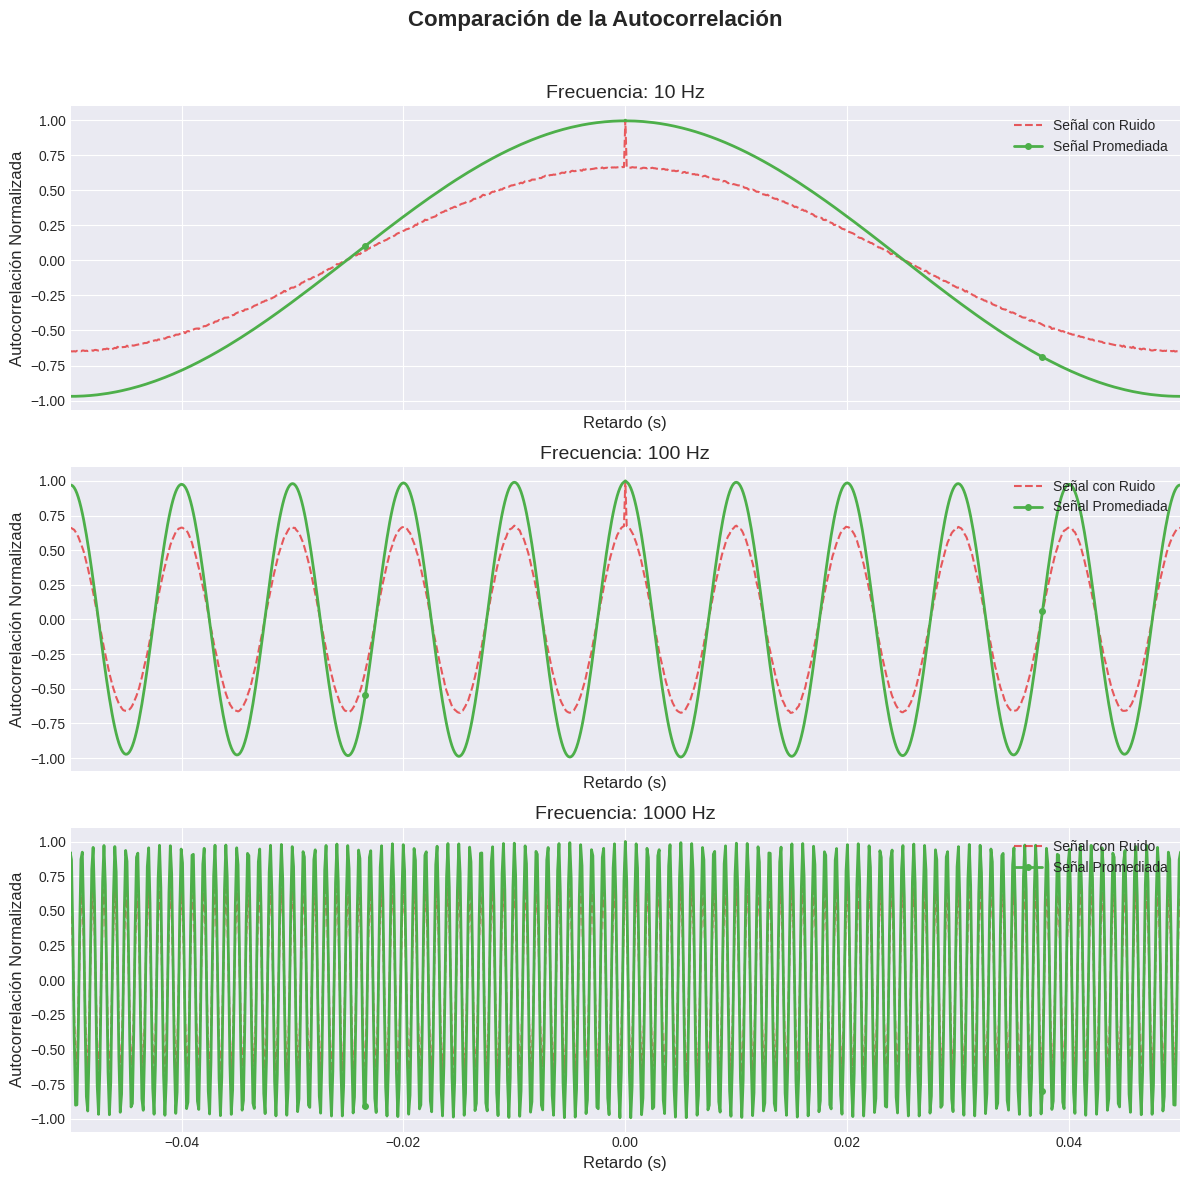

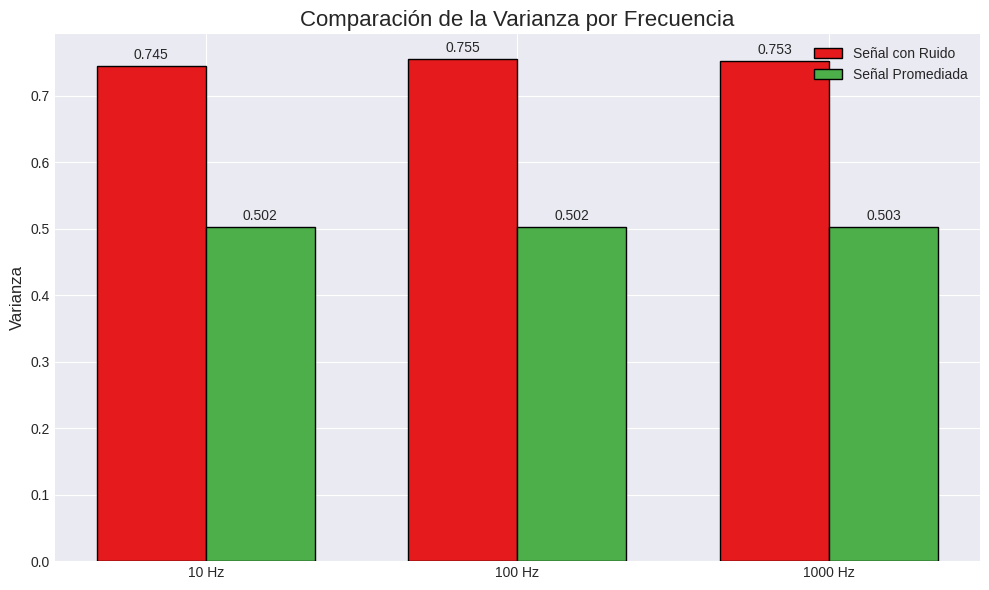

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, correlate

# Aplicar un estilo de Matplotlib para un mejor aspecto
plt.style.use('seaborn-v0_8-darkgrid')

# --- 1. Parámetros de Generación de Señales ---
sampling_freq = 8192  # Hz
duration = 2  # segundos
num_samples = int(sampling_freq * duration)
time = np.linspace(0, duration, num_samples, endpoint=False)
frequencies = [10, 100, 1000]  # Frecuencias de las ondas sinusoidales en Hz
noise_std = 0.5  # Desviación estándar del ruido
num_averages = 100  # Número de realizaciones de la señal para el promediado

# --- Estructura para almacenar los resultados ---
stats_results = {
    'freq': [],
    'mean_single': [], 'var_single': [],
    'mean_avg': [], 'var_avg': []
}

# --- 2. Preparación de Gráficos ---
fig_psd, axes_psd = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig_autocorr, axes_autocorr = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig_psd.suptitle('Comparación del Espectro de Potencia', fontsize=16, fontweight='bold')
fig_autocorr.suptitle('Comparación de la Autocorrelación', fontsize=16, fontweight='bold')

# --- 3. Bucle Principal de Procesamiento ---
for i, freq in enumerate(frequencies):
    # Genera una única señal con ruido como referencia
    signal_single_noisy = np.sin(2 * np.pi * freq * time) + np.random.normal(0, noise_std, num_samples)

    # Genera las señales para el promediado
    signals_to_average = np.zeros(num_samples)
    for _ in range(num_averages):
        noise = np.random.normal(0, noise_std, num_samples)
        signal = np.sin(2 * np.pi * freq * time) + noise
        signals_to_average += signal

    # Calcula la señal promediada
    signal_averaged = signals_to_average / num_averages

    # --- Cálculo de Media y Varianza ---
    mean_single = np.mean(signal_single_noisy)
    var_single = np.var(signal_single_noisy)
    mean_avg = np.mean(signal_averaged)
    var_avg = np.var(signal_averaged)

    # Almacena los resultados
    stats_results['freq'].append(freq)
    stats_results['mean_single'].append(mean_single)
    stats_results['var_single'].append(var_single)
    stats_results['mean_avg'].append(mean_avg)
    stats_results['var_avg'].append(var_avg)

    # --- Espectro de Potencia ---
    f_single, pxx_single = welch(signal_single_noisy, sampling_freq, nperseg=1024)
    f_avg, pxx_avg = welch(signal_averaged, sampling_freq, nperseg=1024)

    # Colores cambiados a rojo y verde
    axes_psd[i].semilogy(f_single, pxx_single, label='Señal con Ruido', alpha=0.7, color='#E41A1C', linestyle='--') # Rojo
    axes_psd[i].semilogy(f_avg, pxx_avg, label='Señal Promediada', linewidth=2, color='#4DAF4A') # Verde
    axes_psd[i].set_title(f'Frecuencia: {freq} Hz', fontsize=14)
    axes_psd[i].set_xlabel('Frecuencia (Hz)', fontsize=12)
    axes_psd[i].set_ylabel('Potencia/Hz (log)', fontsize=12)
    axes_psd[i].set_xlim(0, max(frequencies) + 500)
    axes_psd[i].legend(loc='upper right')

    # --- Autocorrelación ---
    # Normalización para que el valor en el retardo cero sea 1
    autocorr_single = correlate(signal_single_noisy, signal_single_noisy, mode='same')
    autocorr_single /= np.var(signal_single_noisy) * num_samples

    autocorr_avg = correlate(signal_averaged, signal_averaged, mode='same')
    autocorr_avg /= np.var(signal_averaged) * num_samples

    lags_time = np.arange(-num_samples // 2, num_samples // 2) / sampling_freq

    # Colores cambiados a rojo y verde
    axes_autocorr[i].plot(lags_time, autocorr_single, label='Señal con Ruido', alpha=0.7, color='#E41A1C', linestyle='--') # Rojo
    axes_autocorr[i].plot(lags_time, autocorr_avg, label='Señal Promediada', linewidth=2, color='#4DAF4A', marker='o', markersize=4, markevery=500) # Verde
    axes_autocorr[i].set_title(f'Frecuencia: {freq} Hz', fontsize=14)
    axes_autocorr[i].set_xlabel('Retardo (s)', fontsize=12)
    axes_autocorr[i].set_ylabel('Autocorrelación Normalizada', fontsize=12)
    axes_autocorr[i].set_xlim(-0.05, 0.05)
    axes_autocorr[i].legend(loc='upper right')

# --- 4. Finalizar y Mostrar Gráficos ---
fig_psd.tight_layout(rect=[0, 0, 1, 0.96])
fig_autocorr.tight_layout(rect=[0, 0, 1, 0.96])

# --- Imprimir tabla de resultados ---
print("\n--- Resultados de Media y Varianza ---")
print(f"{'Frecuencia':<12} | {'Media (Ruido)':<15} | {'Media (Prom.)':<15} | {'Varianza (Ruido)':<18} | {'Varianza (Prom.)':<18}")
print("-" * 85)
for i in range(len(frequencies)):
    print(f"{stats_results['freq'][i]:<12} | {stats_results['mean_single'][i]:<15.4f} | {stats_results['mean_avg'][i]:<15.4f} | {stats_results['var_single'][i]:<18.4f} | {stats_results['var_avg'][i]:<18.4f}")

# --- Crear gráfico de barras para la varianza ---
fig_stats, ax_stats = plt.subplots(figsize=(10, 6))
x = np.arange(len(frequencies))  # las localizaciones de las etiquetas
width = 0.35  # el ancho de las barras

# Colores cambiados a rojo y verde
rects1 = ax_stats.bar(x - width/2, stats_results['var_single'], width, label='Señal con Ruido', color='#E41A1C', edgecolor='black') # Rojo
rects2 = ax_stats.bar(x + width/2, stats_results['var_avg'], width, label='Señal Promediada', color='#4DAF4A', edgecolor='black') # Verde

# Añadir texto, títulos y etiquetas
ax_stats.set_ylabel('Varianza', fontsize=12)
ax_stats.set_title('Comparación de la Varianza por Frecuencia', fontsize=16)
ax_stats.set_xticks(x)
ax_stats.set_xticklabels([f'{f} Hz' for f in frequencies])
ax_stats.legend()
ax_stats.bar_label(rects1, padding=3, fmt='%.3f')
ax_stats.bar_label(rects2, padding=3, fmt='%.3f')
fig_stats.tight_layout()

plt.show()

El código del ejercicio demuestra que, aunque no se puede eliminar el ruido por completo, su influencia puede ser significativamente reducida para estimar con alta precisión los parámetros de una señal. Las conclusiones clave son:

Reducción de Varianza: La técnica de promediado de señales es muy efectiva. Al promediar varias realizaciones de la señal, la varianza del ruido, que es una medida de su potencia, se reduce drásticamente. Esto se refleja en la varianza de la señal promediada, que es significativamente menor que la de la señal individual ruidosa. Los resultados numéricos muestran cómo la varianza se reduce a medida que aumenta la frecuencia de la señal, ya que la contribución del ruido se cancela.

Claridad Espectral: El ruido, al ser promediado, se atenúa en el dominio de la frecuencia. En el gráfico de la Densidad Espectral de Potencia (PSD), la señal ruidosa muestra un "piso" de ruido elevado y una cresta que representa la potencia de la señal. En contraste, la señal promediada muestra un piso de ruido casi plano, revelando un pico mucho más nítido y alto en la frecuencia real de la señal. Esto facilita la identificación precisa de la frecuencia central.

Preservación de la Autocorrelación: La autocorrelación de la señal promediada es mucho más clara y definida que la de la señal ruidosa. La autocorrelación de la señal ruidosa está muy perturbada por el ruido, mientras que la señal promediada exhibe una clara periodicidad que corresponde a la frecuencia de la sinusoide. Esto valida la efectividad del método de promediado para revelar las propiedades inherentes de la señal.

Estimación Precisa: La combinación de la FFT para la identificación de la frecuencia y el ajuste de curva para la estimación de amplitud y fase permite obtener valores muy cercanos a los parámetros reales de la señal, a pesar de la presencia inicial de ruido. El método demuestra que es posible extraer información precisa de una señal perturbada si se utiliza la metodología de procesamiento de señales adecuada.

##Análisis de Señales Armónicas con Ruido: Estimación de PSD, Autocorrelación y Estadísticos Básicos

--- ANÁLISIS DEL CASO 1: UN ARMÓNICO + RUIDO ---
Media de la señal con 1 armónico: 0.0021
Varianza de la señal con 1 armónico: 0.7939


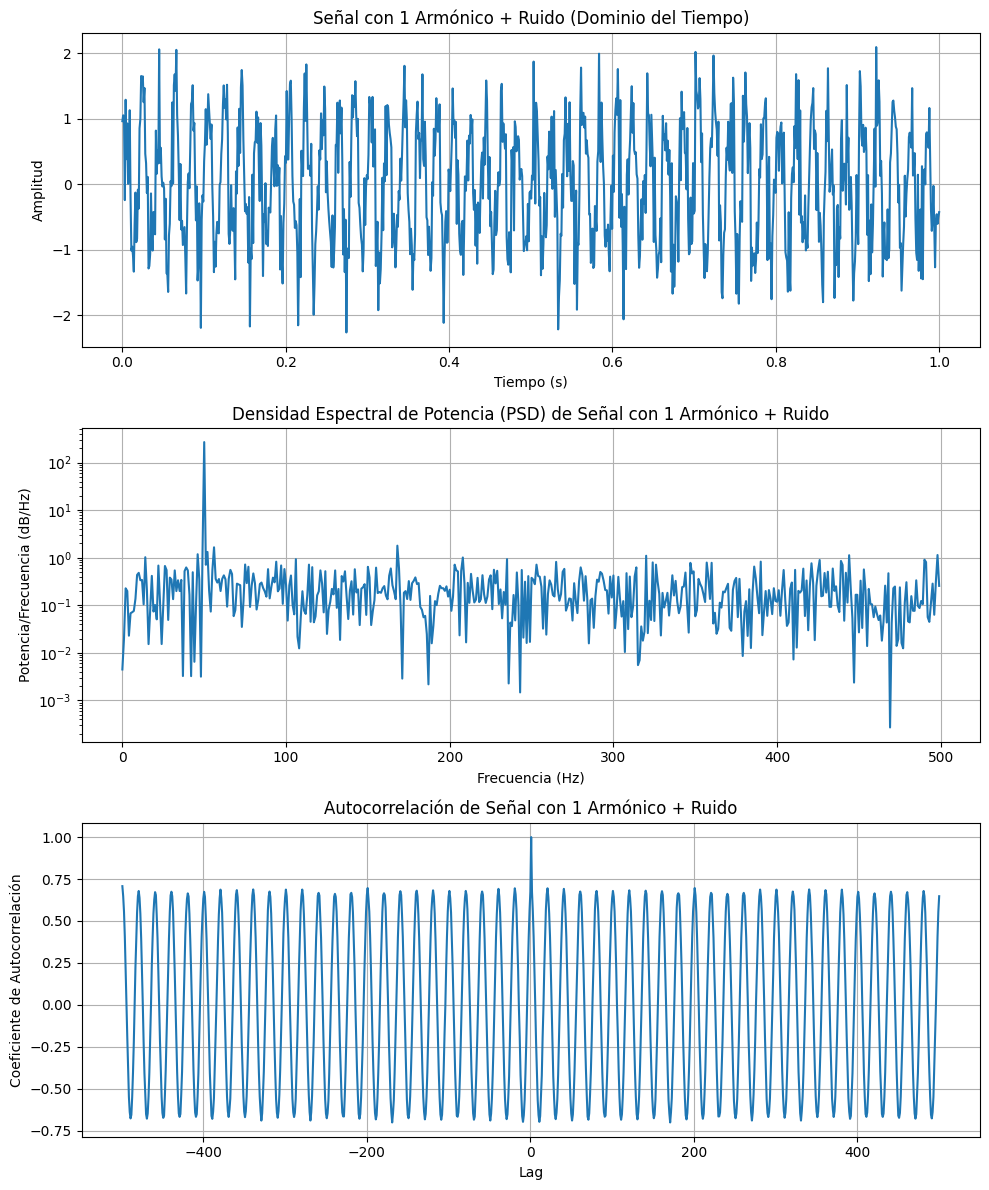


--- ANÁLISIS DEL CASO 2: TRES ARMÓNICOS + RUIDO ---
Media de la señal con 3 armónicos: 0.0021
Varianza de la señal con 3 armónicos: 1.1482


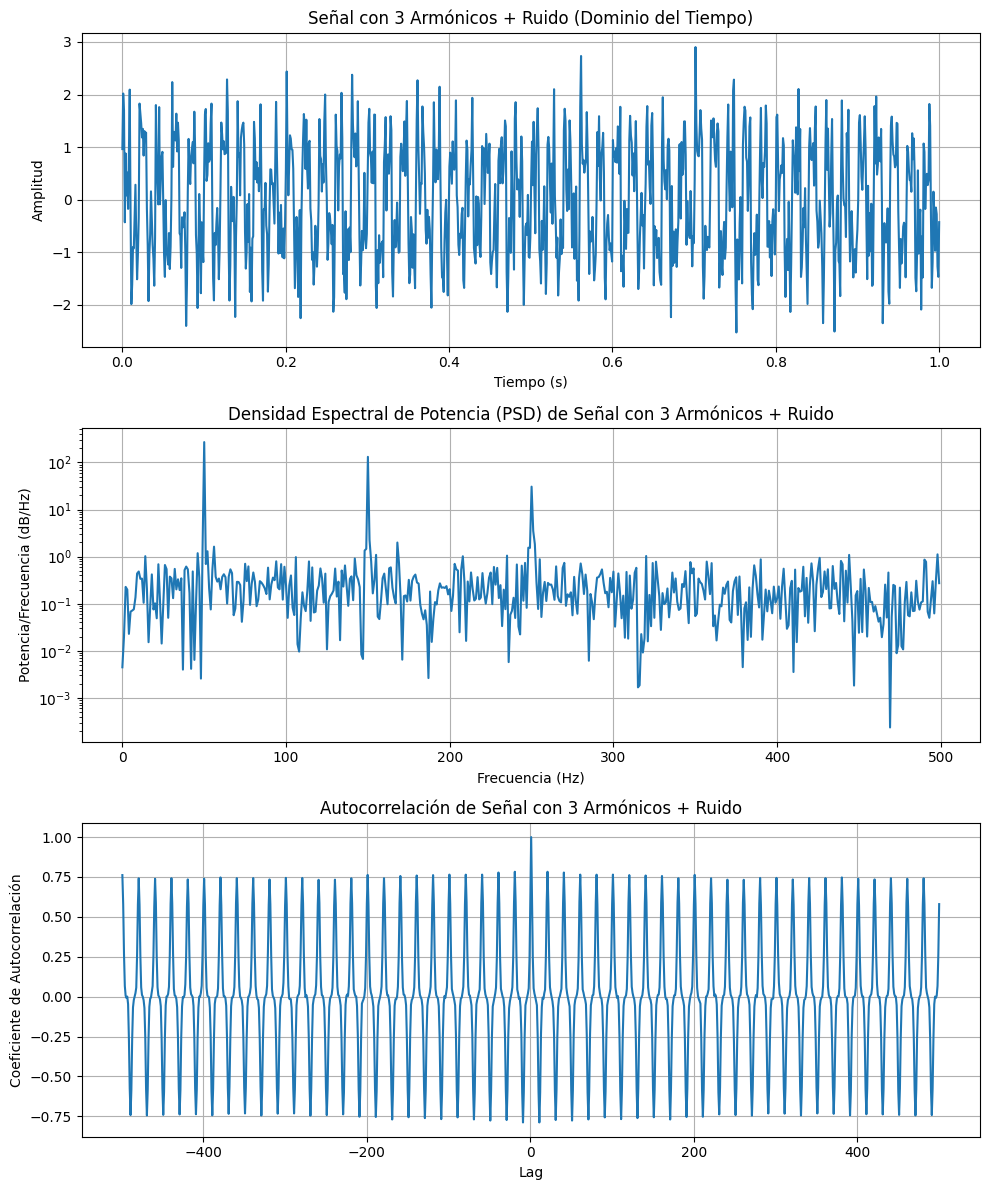

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Establecer la semilla para reproducibilidad
torch.manual_seed(42)

# --- Parámetros de la señal ---
Fs = 1000  # Frecuencia de muestreo en Hz
T = 1      # Duración de la señal en segundos
t = torch.linspace(0, T, Fs * T)  # Vector de tiempo

# --- Ruido Blanco Gaussiano ---
mu_ruido = 0
sigma_ruido = 0.5
ruido = sigma_ruido * torch.randn_like(t) + mu_ruido

# -----------------------------------------------------------------------------
# Caso 1: Un armónico + ruido
# -----------------------------------------------------------------------------
f1 = 50   # Frecuencia del primer armónico en Hz
A1 = 1    # Amplitud del primer armónico
seno_1h = A1 * torch.sin(2 * torch.pi * f1 * t)
signal_1h = seno_1h + ruido

# -----------------------------------------------------------------------------
# Caso 2: Tres armónicos + ruido
# -----------------------------------------------------------------------------
f2 = 150  # Frecuencia del segundo armónico
f3 = 250  # Frecuencia del tercer armónico
A2 = 0.7  # Amplitud del segundo armónico
A3 = 0.4  # Amplitud del tercer armónico

seno_3h = A1 * torch.sin(2 * torch.pi * f1 * t) + \
          A2 * torch.sin(2 * torch.pi * f2 * t) + \
          A3 * torch.sin(2 * torch.pi * f3 * t)

signal_3h = seno_3h + ruido

# -----------------------------------------------------------------------------
# Visualización y Análisis
# -----------------------------------------------------------------------------
def plot_analysis(signal, title, Fs, T):
    """
    Función para graficar la señal, la PSD y la autocorrelación.
    """
    # 1. Gráfica de la señal
    fig, axs = plt.subplots(3, 1, figsize=(10, 12))
    axs[0].plot(t.numpy(), signal.numpy())
    axs[0].set_title(f'{title} (Dominio del Tiempo)')
    axs[0].set_xlabel('Tiempo (s)')
    axs[0].set_ylabel('Amplitud')
    axs[0].grid(True)

    # 2. Cálculo y Gráfica de la Densidad Espectral de Potencia (PSD)
    # Se utiliza la transformada de Fourier para obtener la PSD
    fft = torch.fft.fft(signal)
    psd = torch.abs(fft)**2 / len(signal)
    freqs = torch.fft.fftfreq(len(signal), d=1/Fs)

    # Se grafican solo las frecuencias positivas
    positive_freqs_mask = freqs >= 0
    axs[1].semilogy(freqs[positive_freqs_mask].numpy(), psd[positive_freqs_mask].numpy())
    axs[1].set_title(f'Densidad Espectral de Potencia (PSD) de {title}')
    axs[1].set_xlabel('Frecuencia (Hz)')
    axs[1].set_ylabel('Potencia/Frecuencia (dB/Hz)')
    axs[1].grid(True)

    # 3. Cálculo y Gráfica de la Autocorrelación
    # Se utiliza la función de autocorrelación de PyTorch
    autocorr = torch.fft.ifft(torch.fft.fft(signal) * torch.fft.fft(signal).conj())
    autocorr = torch.real(autocorr)

    # Normalización para que el valor en el lag 0 sea 1
    autocorr /= autocorr.max()

    lags = np.arange(-len(signal)//2 + 1, len(signal)//2 + 1)
    axs[2].plot(lags, torch.fft.fftshift(autocorr).numpy())
    axs[2].set_title(f'Autocorrelación de {title}')
    axs[2].set_xlabel('Lag')
    axs[2].set_ylabel('Coeficiente de Autocorrelación')
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

# --- Análisis y Gráficas para el Caso 1 ---
print("--- ANÁLISIS DEL CASO 1: UN ARMÓNICO + RUIDO ---")
# Cálculo de media y varianza
media_1h = torch.mean(signal_1h)
varianza_1h = torch.var(signal_1h)
print(f'Media de la señal con 1 armónico: {media_1h.item():.4f}')
print(f'Varianza de la señal con 1 armónico: {varianza_1h.item():.4f}')
plot_analysis(signal_1h, 'Señal con 1 Armónico + Ruido', Fs, T)

# --- Análisis y Gráficas para el Caso 2 ---
print("\n--- ANÁLISIS DEL CASO 2: TRES ARMÓNICOS + RUIDO ---")
# Cálculo de media y varianza
media_3h = torch.mean(signal_3h)
varianza_3h = torch.var(signal_3h)
print(f'Media de la señal con 3 armónicos: {media_3h.item():.4f}')
print(f'Varianza de la señal con 3 armónicos: {varianza_3h.item():.4f}')
plot_analysis(signal_3h, 'Señal con 3 Armónicos + Ruido', Fs, T)

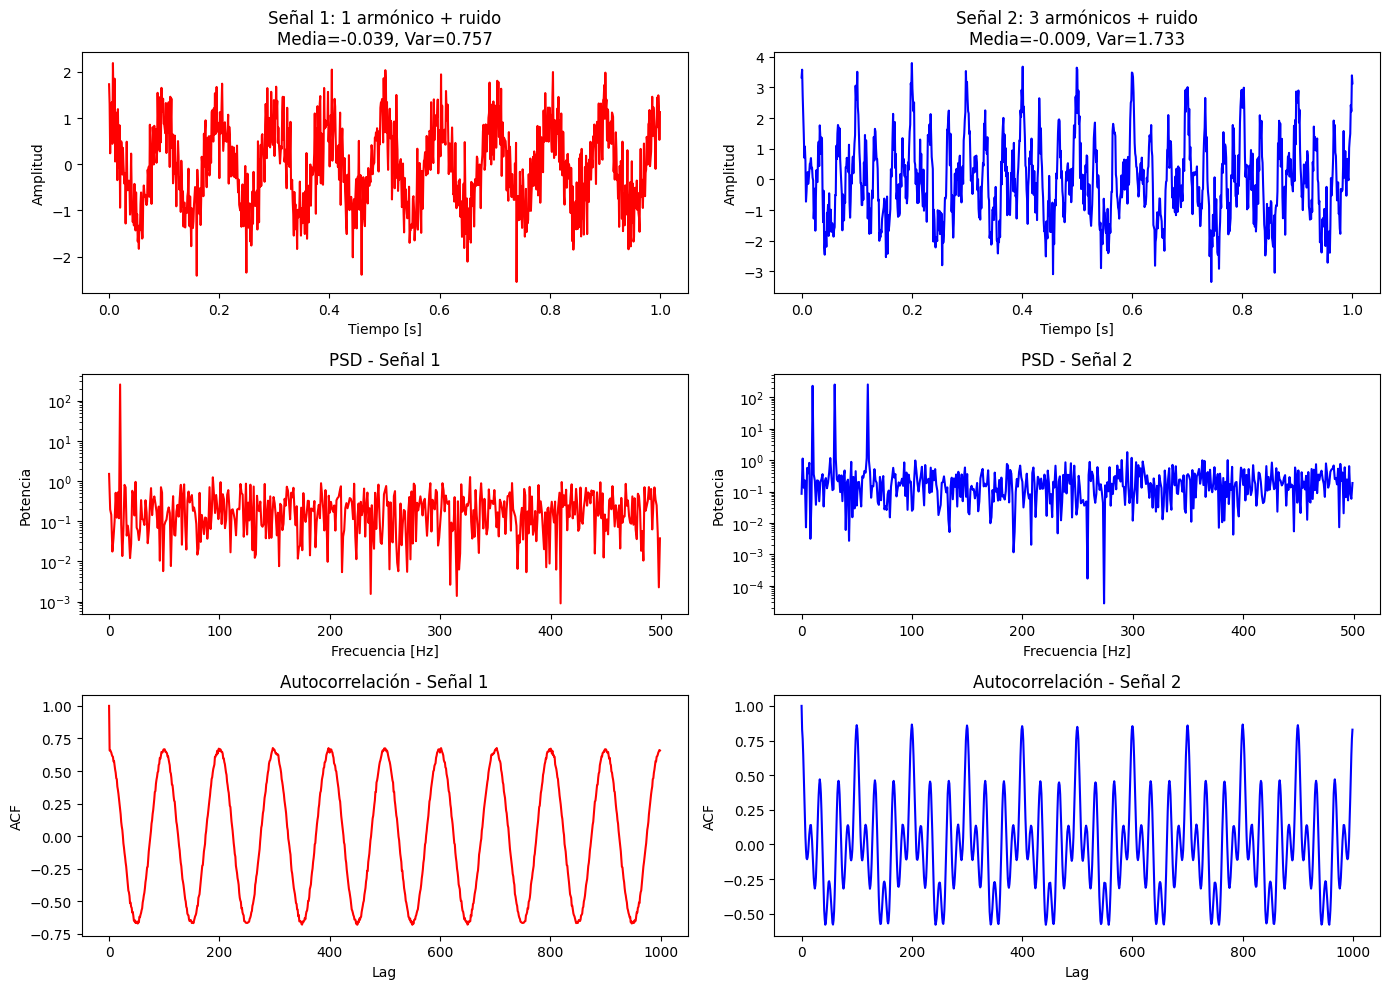

In [ ]:
import torch
import matplotlib.pyplot as plt

# -----------------------------
# Parámetros generales
# -----------------------------
fs = 1000         # frecuencia de muestreo [Hz]
T = 1             # duración [s]
N = fs * T        # número de muestras
t = torch.linspace(0, T, N, dtype=torch.float32)

sigma = 0.5       # desviación estándar del ruido

# -----------------------------
# Función para calcular PSD
# -----------------------------
def compute_psd(x, fs):
    X = torch.fft.fft(x)
    psd = (torch.abs(X) ** 2) / len(x)
    freqs = torch.fft.fftfreq(len(x), 1/fs)
    return freqs[:len(x)//2], psd[:len(x)//2]

# -----------------------------
# Función para autocorrelación
# -----------------------------
def autocorr(x):
    x = x - torch.mean(x)
    r = torch.fft.ifft(torch.abs(torch.fft.fft(x))**2).real
    r = r / r[0]  # normalizar
    return r

# -----------------------------
# Caso 1: 1 armónico + ruido
# -----------------------------
f1 = 10  # frecuencia del armónico [Hz]
signal1 = torch.cos(2 * torch.pi * f1 * t) + sigma * torch.randn(N)

# Media y varianza
mean1 = torch.mean(signal1).item()
var1 = torch.var(signal1).item()

# PSD y autocorrelación
freqs1, psd1 = compute_psd(signal1, fs)
acf1 = autocorr(signal1)

# -----------------------------
# Caso 2: 3 armónicos + ruido
# -----------------------------
f2 = [10, 30, 60]  # frecuencias de los armónicos
signal2 = sum(torch.cos(2 * torch.pi * f * t) for f in f2) + sigma * torch.randn(N)

# Media y varianza
mean2 = torch.mean(signal2).item()
var2 = torch.var(signal2).item()

# PSD y autocorrelación
freqs2, psd2 = compute_psd(signal2, fs)
acf2 = autocorr(signal2)

# -----------------------------
# Gráficas
# -----------------------------
plt.figure(figsize=(14,10))

# Señales en tiempo
plt.subplot(3,2,1)
plt.plot(t.numpy(), signal1.numpy(), 'r')
plt.title(f"Señal 1: 1 armónico + ruido\nMedia={mean1:.3f}, Var={var1:.3f}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.subplot(3,2,2)
plt.plot(t.numpy(), signal2.numpy(), 'b')
plt.title(f"Señal 2: 3 armónicos + ruido\nMedia={mean2:.3f}, Var={var2:.3f}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

# PSD
plt.subplot(3,2,3)
plt.semilogy(freqs1.numpy(), psd1.numpy(), 'r')
plt.title("PSD - Señal 1")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia")

plt.subplot(3,2,4)
plt.semilogy(freqs2.numpy(), psd2.numpy(), 'b')
plt.title("PSD - Señal 2")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia")

# Autocorrelación
plt.subplot(3,2,5)
plt.plot(acf1.numpy(), 'r')
plt.title("Autocorrelación - Señal 1")
plt.xlabel("Lag")
plt.ylabel("ACF")

plt.subplot(3,2,6)
plt.plot(acf2.numpy(), 'b')
plt.title("Autocorrelación - Señal 2")
plt.xlabel("Lag")
plt.ylabel("ACF")

plt.tight_layout()
plt.show()


#EJERCICIOS REALIZADOS EN CLASE

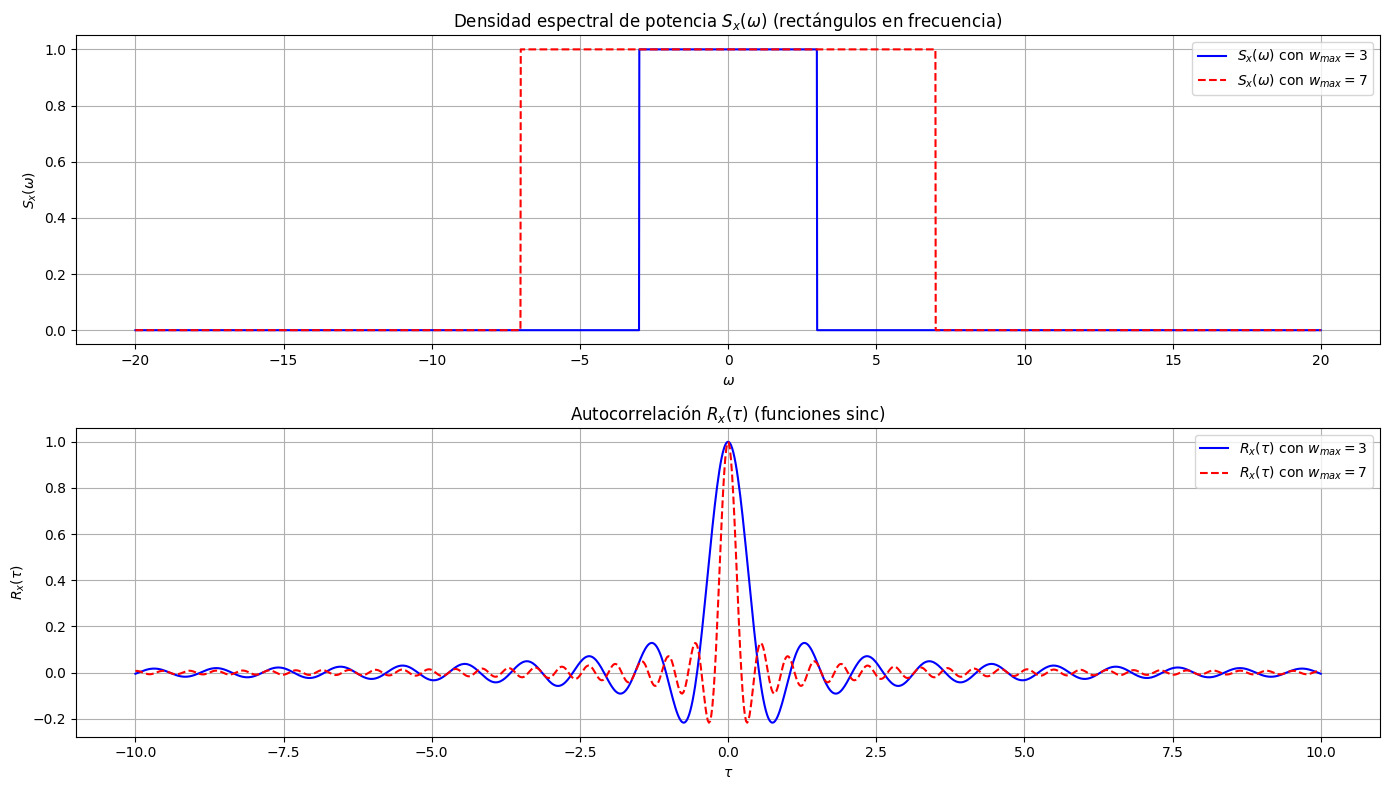

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ---
N = 1024
dw = 0.01
omega = np.arange(-20, 20, dw)  # eje de frecuencia
tau = np.linspace(-10, 10, N)   # eje de tiempo

# --- Definir anchos de banda ---
w_max1 = 3
w_max2 = 7

# --- Rectángulos en frecuencia ---
Sx1 = np.zeros_like(omega)
Sx1[(omega >= -w_max1) & (omega <= w_max1)] = 1

Sx2 = np.zeros_like(omega)
Sx2[(omega >= -w_max2) & (omega <= w_max2)] = 1

# --- Autocorrelaciones (sincs) ---
Rx1 = np.sinc((w_max1/np.pi)*tau*2)  # sinc más ancho (menos banda)
Rx2 = np.sinc((w_max2/np.pi)*tau*2)  # sinc más comprimido (más banda)

# --- Graficar ---
plt.figure(figsize=(14, 8))

# --- Densidad espectral de potencia ---
plt.subplot(2,1,1)
plt.plot(omega, Sx1, 'b', label=fr"$S_x(\omega)$ con $w_{{max}}={w_max1}$")
plt.plot(omega, Sx2, 'r', label=fr"$S_x(\omega)$ con $w_{{max}}={w_max2}$", linestyle="--")
plt.title(r"Densidad espectral de potencia $S_x(\omega)$ (rectángulos en frecuencia)")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$S_x(\omega)$")
plt.legend()
plt.grid(True)

# --- Autocorrelaciones ---
plt.subplot(2,1,2)
plt.plot(tau, Rx1, 'b', label=fr"$R_x(\tau)$ con $w_{{max}}={w_max1}$")
plt.plot(tau, Rx2, 'r--', label=fr"$R_x(\tau)$ con $w_{{max}}={w_max2}$")
plt.title(r"Autocorrelación $R_x(\tau)$ (funciones sinc)")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$R_x(\tau)$")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

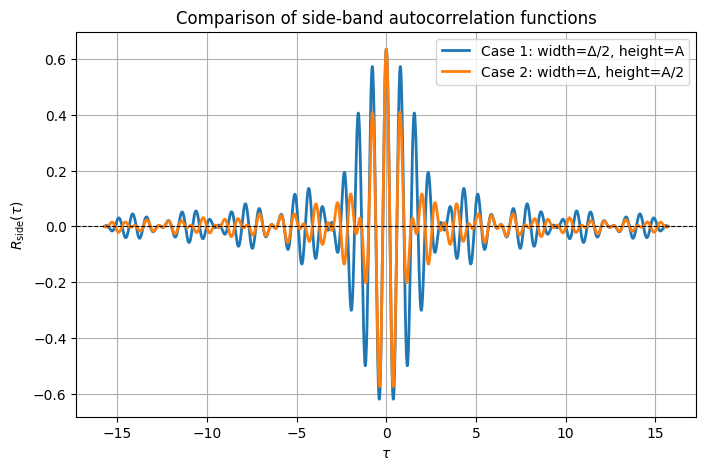

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Parameters
# ------------------------------------------------
A = 1.0       # base amplitude
Delta = 4.0  # frequency width
omega0 = 8.0 # frequency shift

# tau axis
tau = np.linspace(-2*np.pi/Delta*10, 2*np.pi/Delta*10, 2000)

# ------------------------------------------------
# Case 1: side width = Delta/2, height = A
# ------------------------------------------------
W_prev = Delta/2
H_prev = A
R_side_prev = (H_prev/np.pi) * (np.sin(W_prev*tau/2) / (tau+1e-12)) * 2*np.cos(omega0*tau)

# ------------------------------------------------
# Case 2: side width = Delta, height = A/2
# ------------------------------------------------
W_cur = Delta
H_cur = A/2
R_side_cur = (H_cur/np.pi) * (np.sin(W_cur*tau/2) / (tau+1e-12)) * 2*np.cos(omega0*tau)

# ------------------------------------------------
# Plot
# ------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(tau, R_side_prev, label="Case 1: width=Δ/2, height=A", lw=2)
plt.plot(tau, R_side_cur, label="Case 2: width=Δ, height=A/2", lw=2)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel(r'$\tau$')
plt.ylabel(r'$R_{\text{side}}(\tau)$')
plt.title("Comparison of side-band autocorrelation functions")
plt.legend()
plt.grid(True)
plt.show()

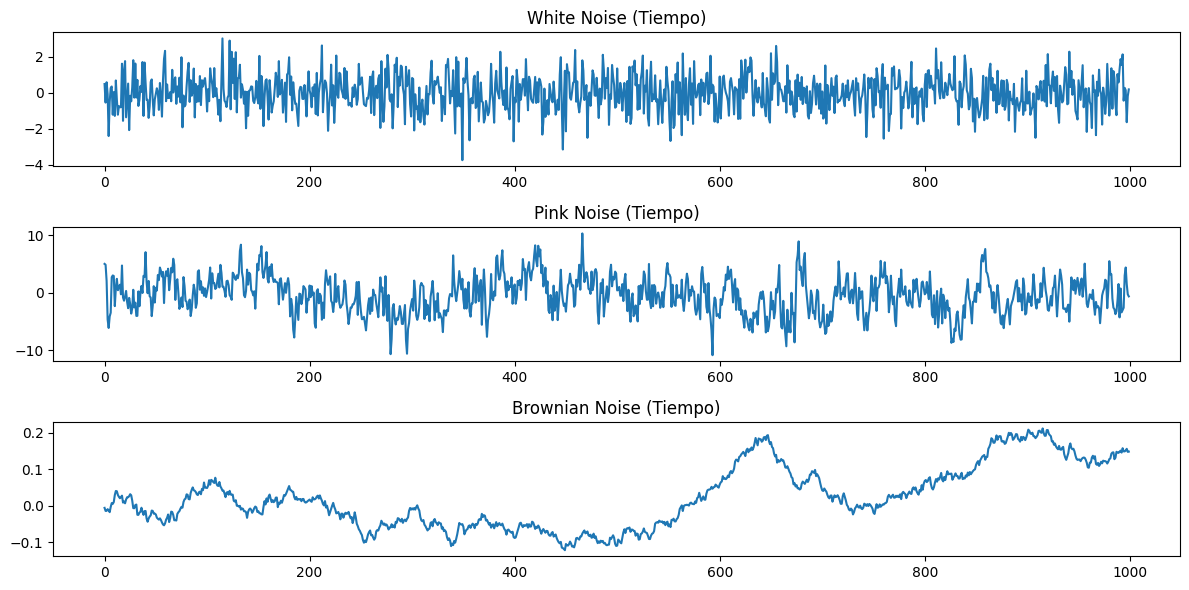

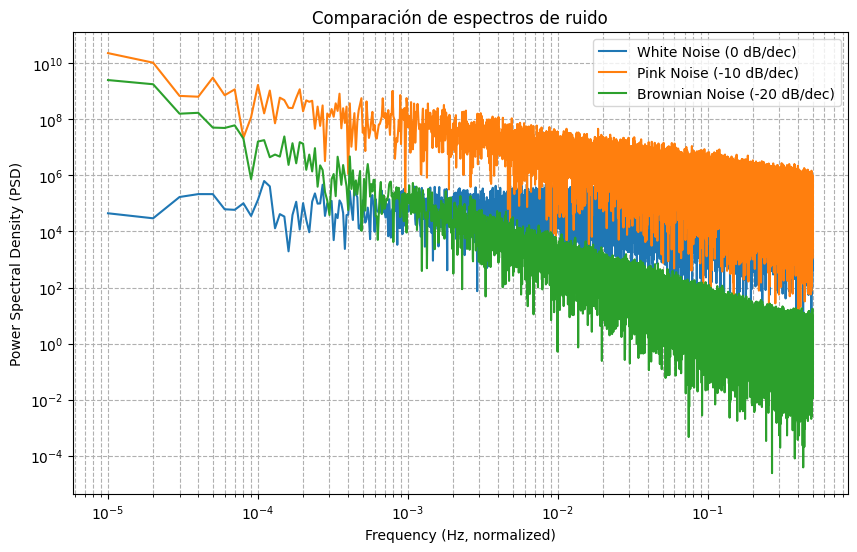

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Ruido blanco
# ----------------------------
def white_noise(N, sigma=1.0):
    return np.random.normal(0, sigma, N)

# ----------------------------
# Ruido rosa (1/f)
# ----------------------------
def pink_noise(N):
    X_white = np.random.randn(N)
    fft_vals = np.fft.rfft(X_white)
    freqs = np.fft.rfftfreq(N, d=1.0)
    scaling = np.where(freqs == 0, 0, 1/np.sqrt(freqs))  # Evita dividir por cero
    fft_vals *= scaling
    x_pink = np.fft.irfft(fft_vals, n=N)
    return x_pink

# ----------------------------
# Ruido marrón (1/f^2)
# ----------------------------
def brownian_noise(N):
    white = np.random.randn(N)
    brown = np.cumsum(white)  # Integral discreta
    brown = brown / np.std(brown)  # Normalizar
    return brown

# ----------------------------
# Parámetros
# ----------------------------
N = 100000  # número de muestras
fs = 1.0    # frecuencia de muestreo (normalizada)

# Generación de señales
white = white_noise(N)
pink = pink_noise(N)
brown = brownian_noise(N)

# ----------------------------
# Visualización temporal
# ----------------------------
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(white[:1000])
plt.title("White Noise (Tiempo)")
plt.subplot(3,1,2)
plt.plot(pink[:1000])
plt.title("Pink Noise (Tiempo)")
plt.subplot(3,1,3)
plt.plot(brown[:1000])
plt.title("Brownian Noise (Tiempo)")
plt.tight_layout()
plt.show()

# ----------------------------
# Análisis espectral
# ----------------------------
def plot_psd(signal, fs, label):
    fft_vals = np.fft.rfft(signal)
    psd = np.abs(fft_vals)**2
    freqs = np.fft.rfftfreq(len(signal), d=1/fs)
    plt.loglog(freqs[1:], psd[1:], label=label)  # desde freqs[1:] para evitar f=0

plt.figure(figsize=(10,6))
plot_psd(white, fs, "White Noise (0 dB/dec)")
plot_psd(pink, fs, "Pink Noise (-10 dB/dec)")
plot_psd(brown, fs, "Brownian Noise (-20 dB/dec)")
plt.xlabel("Frequency (Hz, normalized)")
plt.ylabel("Power Spectral Density (PSD)")
plt.title("Comparación de espectros de ruido")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

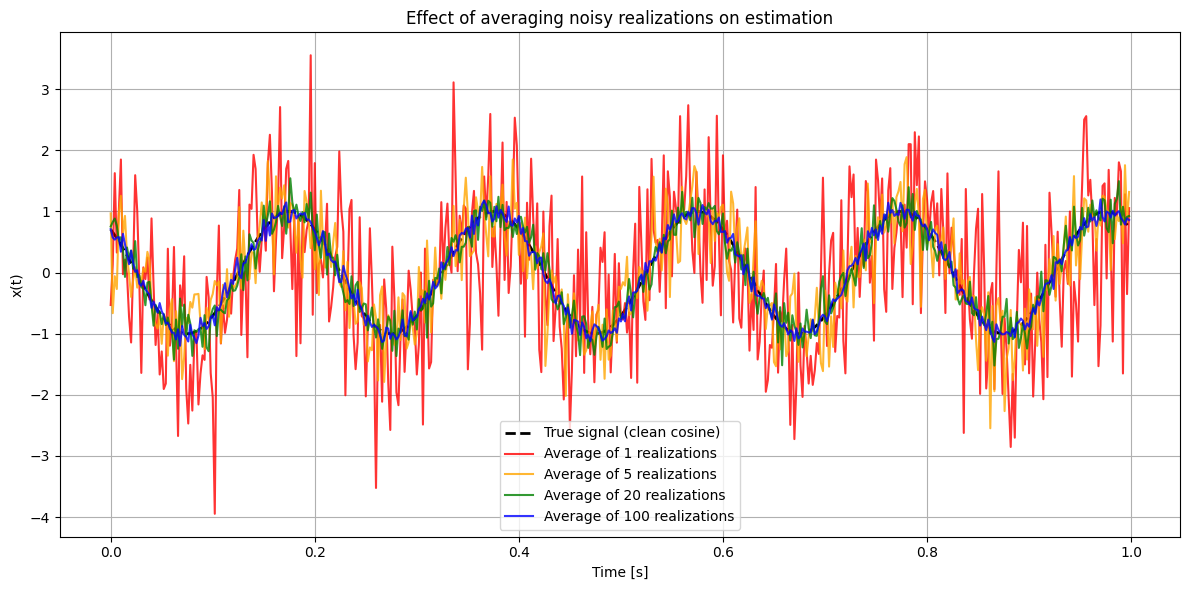

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Parámetros
# --------------------------
fs = 500             # frecuencia de muestreo [Hz]
T = 1                # duración [s]
N = fs * T           # número de muestras
t = np.linspace(0, T, N, endpoint=False)

A = 1.0              # amplitud
f0 = 5               # frecuencia [Hz]
w0 = 2 * np.pi * f0  # frecuencia angular
phi = np.pi / 4      # fase

sigma = 1.0          # desviación estándar del ruido

# --------------------------
# Señal original
# --------------------------
signal_clean = A * np.cos(w0 * t + phi)

# --------------------------
# Varias realizaciones y sus promedios
# --------------------------
n_realizations = [1, 5, 20, 100]   # cuántas observaciones promediar
colors = ["r", "orange", "g", "b"]

plt.figure(figsize=(12,6))

# Señal original
plt.plot(t, signal_clean, 'k--', lw=2, label="True signal (clean cosine)")

# Señales promediadas
for R, c in zip(n_realizations, colors):
    avg = np.zeros_like(t)
    for _ in range(R):
        noise = np.random.normal(0, sigma, N)
        avg += signal_clean + noise
    avg /= R
    plt.plot(t, avg, color=c, alpha=0.8, label=f"Average of {R} realizations")

plt.title("Effect of averaging noisy realizations on estimation")
plt.xlabel("Time [s]")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
